# Long Only Portfolio

## Portfolio Rules

- Rebalance Every 21 Trading Days
- Select Top 20 Predicted Stocks
- Equal Weight Allocation

## Objective

Evaluate whether ML predictions generate investable alpha.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

test = pd.read_csv(
    "v2_predictions.csv",
    index_col=[0,1],
    parse_dates=[0]
)

print(test.shape)

test.head()

(321028, 20)


mom21     mom63    mom126     vol21     vol63  \
Date                                                                        
2022-01-03 3MINDIA.NS   -0.000492  0.037566  0.060943  0.015019  0.014196   
           ABB.NS        0.061129  0.186427  0.229553  0.028616  0.024826   
           ACC.NS       -0.004796  0.006190  0.127931  0.016365  0.015481   
           AIAENG.NS     0.008258 -0.037923 -0.118066  0.013237  0.012564   
           APLAPOLLO.NS  0.025720  0.118160  0.155668  0.026467  0.024544   

                         ema_distance  ema_slope      rsi14  future_return  \
Date                                                                         
2022-01-03 3MINDIA.NS        0.020394  -0.004152  61.477420      -0.031571   
           ABB.NS            0.038912   0.025155  42.984065       0.041375   
           ACC.NS           -0.007693  -0.021376  41.161351       0.024519   
           AIAENG.NS        -0.003623  -0.010820  54.338304       0.033490   
           APLAPOLLO.NS     -0.000077   0.029442  28.654798      -0.027867   

                         market_mom21  market_vol21  rank_mom21  rank_mom63  \
Date                                                                          
2022-01-03 3MINDIA.NS        0.039417      0.012684    0.364458    0.629518   
           ABB.NS            0.039417      0.012684    0.686747    0.870482   
           ACC.NS            0.039417      0.012684    0.328313    0.524096   
           AIAENG.NS         0.039417      0.012684    0.424699    0.337349   
           APLAPOLLO.NS      0.039417      0.012684    0.518072    0.774096   

                         rank_mom126  rank_vol21  rank_vol63  rank_rsi14  \
Date                                                                       
2022-01-03 3MINDIA.NS       0.451807    0.174699    0.078313    0.795181   
           ABB.NS           0.689759    0.834337    0.596386    0.277108   
           ACC.NS           0.551205    0.246988    0.108434    0.216867   
           AIAENG.NS        0.147590    0.090361    0.039157    0.614458   
           APLAPOLLO.NS     0.596386    0.780120    0.581325    0.036145   

                         future_relative_return  prediction  pred_bucket  
Date                                                                      
2022-01-03 3MINDIA.NS                 -0.053508   -0.000927            5  
           ABB.NS                      0.019438    0.000209            5  
           ACC.NS                      0.002582   -0.000928            5  
           AIAENG.NS                   0.011554   -0.006534            1  
           APLAPOLLO.NS               -0.049804   -0.001740            4

In [2]:
test["prediction"].describe()

count    321028.000000
mean         -0.000406
std           0.009954
min          -0.160373
25%          -0.005418
50%          -0.001140
75%           0.004279
max           0.318102
Name: prediction, dtype: float64

In [12]:
rebalance_dates = (
    test.index
    .get_level_values(0)
    .unique()[::21]
)

portfolio_returns = []

dates = []

for date in rebalance_dates:

    group = test.loc[date]

    top20 = (
        group
        .nlargest(
            20,
            "prediction"
        )
    )

    portfolio_return = (
        top20[
            "future_return"
        ]
        .mean()
    )

    portfolio_returns.append(
        portfolio_return
    )

    dates.append(
        date
    )

In [13]:
portfolio_returns = pd.Series(
    portfolio_returns,
    index=dates
)

portfolio_value = (
    1 +
    portfolio_returns
).cumprod()

portfolio_value.head()

2022-01-03    1.060124
2022-02-02    0.973090
2022-03-04    1.110418
2022-04-05    1.054930
2022-05-09    1.090749
dtype: float64

In [14]:
benchmark_returns = []

for date in rebalance_dates:

    group = test.loc[date]

    benchmark_returns.append(

        group[
            "future_return"
        ].mean()

    )

benchmark_returns = pd.Series(
    benchmark_returns,
    index=dates
)

benchmark_value = (
    1 +
    benchmark_returns
).cumprod()

In [15]:
def performance_stats(
    returns
):

    equity = (
        1 +
        returns
    ).cumprod()

    total_return = (
        equity.iloc[-1]
        - 1
    )

    years = (
        equity.index[-1]
        -
        equity.index[0]
    ).days / 365.25

    cagr = (
        equity.iloc[-1]
        **
        (1 / years)
        - 1
    )

   

    sharpe = (
    returns.mean()
    /
    returns.std()
    *
    np.sqrt(252/21)
    )

    drawdown = (
        equity
        /
        equity.cummax()
        - 1
    )

    max_dd = drawdown.min()

    return pd.Series({

        "Total Return":
            total_return,

        "CAGR":
            cagr,

        "Sharpe":
            sharpe,

        "Max DD":
            max_dd

    })

In [16]:
comparison = pd.DataFrame({

    "ML Portfolio":
        performance_stats(
            portfolio_returns
        ),

    "Benchmark":
        performance_stats(
            benchmark_returns
        )

})

comparison

,ML Portfolio,Benchmark
Total Return,1.664360,1.514316
CAGR,0.284864,0.265955
Sharpe,1.284412,1.452132
Max DD,-0.215659,-0.171204


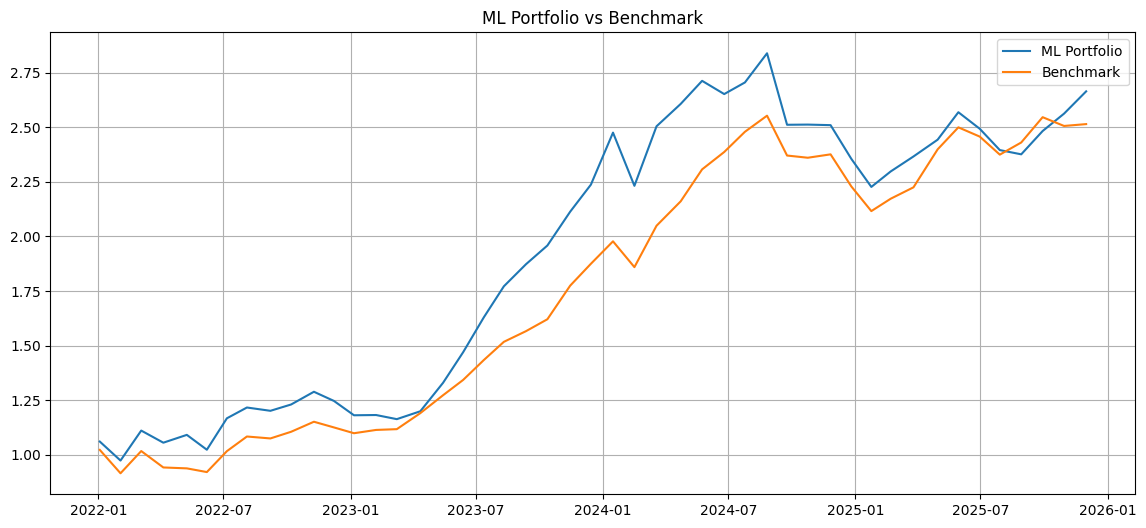

In [17]:
plt.figure(
    figsize=(14,6)
)

plt.plot(
    portfolio_value,
    label="ML Portfolio"
)

plt.plot(
    benchmark_value,
    label="Benchmark"
)

plt.title(
    "ML Portfolio vs Benchmark"
)

plt.legend()

plt.grid(True)

plt.show()

In [18]:
decile_returns = {}

for decile in range(10):

    returns = []

    for date, group in test.groupby(
        level=0
    ):

        group = group.copy()

        group["bucket"] = pd.qcut(

            group["prediction"],

            10,

            labels=False

        )

        selected = group[
            group["bucket"]
            == decile
        ]

        returns.append(

            selected[
                "future_return"
            ].mean()

        )

    decile_returns[
        decile
    ] = np.mean(
        returns
    )

pd.Series(
    decile_returns
)

0    0.016712
1    0.016998
2    0.018962
3    0.018226
4    0.019612
5    0.022663
6    0.022063
7    0.023851
8    0.026133
9    0.024296
dtype: float64

In [19]:
spread_returns = []

for date in rebalance_dates:

    group = test.loc[date]

    top20 = (
        group
        .nlargest(
            20,
            "prediction"
        )
    )

    bottom20 = (
        group
        .nsmallest(
            20,
            "prediction"
        )
    )

    spread = (

        top20[
            "future_return"
        ].mean()

        -

        bottom20[
            "future_return"
        ].mean()

    )

    spread_returns.append(
        spread
    )

spread_returns = pd.Series(
    spread_returns,
    index=dates
)

print(
    "Average 21-Day Spread:",
    spread_returns.mean()
)

Average 21-Day Spread: 0.010219555414590855


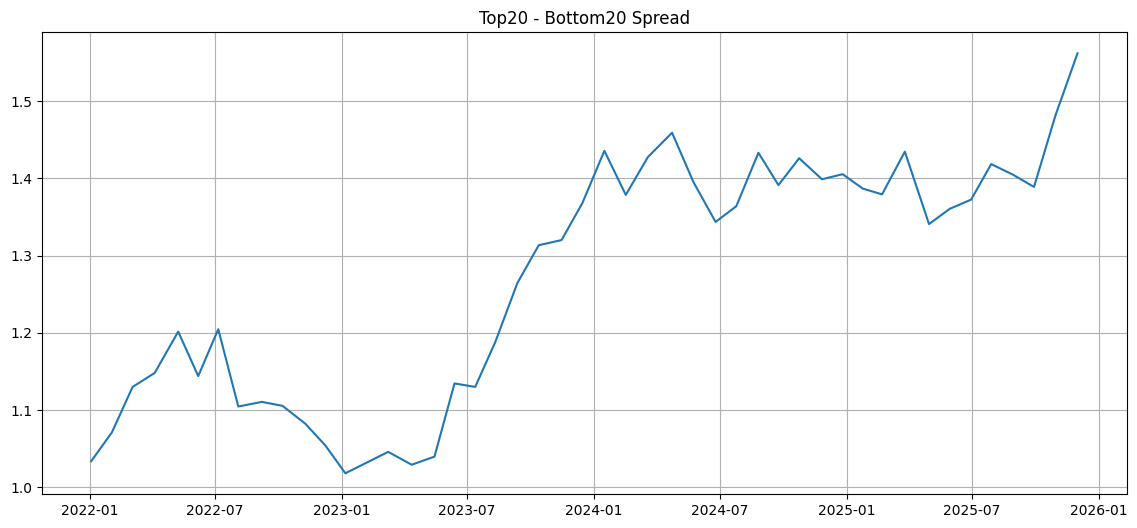

In [20]:
spread_equity = (
    1 +
    spread_returns
).cumprod()

plt.figure(
    figsize=(14,6)
)

plt.plot(
    spread_equity
)

plt.title(
    "Top20 - Bottom20 Spread"
)

plt.grid(True)

plt.show()